# Data Analysis Project
## Analyzing Insurance Auto Claims


## Introduction

This project analyzes a dataset of auto claims filed by customers of an automobile insurance company located in the southwest and western United States.

Insurance companies depend on accurate pricing estimates to maintain profitability. Auto policies must be priced so the company remains profitable given the costs of accident repairs, total loss replacements, medical fees, and legal fees for its customers.

This insurance company had noticed declining profitability over recent years, so this analysis explores the claims data to surface patterns in pricing, customer behavior, and policy structure that could inform pricing and policy adjustments.

The goal of this project is to perform an exploratory data analysis on the `claims_df` dataset and summarize key insights and recommendations.


## Auto Claims Data

The `claims_df` data frame is loaded below and consists of 6,249 auto claims submitted by customers of the insurance company. The rows in this data frame represent a single claim with all of the associated features that are displayed in the table below.

### Data Definitions

| Variable                	| Definition                                                  	| Data Type 	|
|:------------------------- |:------------------------------------------------------------- |:------------- |
| customer_id             	| Customer identifier                                         	| Character 	|
| customer_state          	| State of residence                                          	| Factor    	|
| highest_education       	| Highest level of education                                  	| Factor    	|
| employment_status       	| Employment status at time of claim                          	| Factor    	|
| gender                  	| Gender                                                      	| Factor    	|
| income                  	| Income (US Dollars)                                         	| Numeric   	|
| residence_type          	| Customer residence type                                     	| Factor    	|
| marital_status          	| Marital status                                              	| Factor    	|
| sales_channel           	| Customer acquisition method                                 	| Factor    	|
| coverage                	| Auto policy tier                                            	| Factor    	|
| policy                  	| Auto policy type                                            	| Factor    	|
| vehicle_class           	| Vehicle type                                                	| Factor    	|
| vehicle_size            	| Vehicle size                                                	| Factor    	|
| monthly_premium         	| Customer monthly premium                                    	| Numeric   	|
| months_policy_active    	| Number of months policy has been active                     	| Numeric   	|
| months_since_last_claim 	| Number of months since last claim                           	| Numeric   	|
| current_claim_amount    	| Current claim amount                                        	| Numeric   	|
| total_claims            	| Total number of claims in customer history                  	| Numeric   	|
| total_claims_amount     	| Total amount of all claims in customer history              	| Numeric   	|
| customer_lifetime_value 	| Customer lifetime value (total revenue - total claims cost) 	| Numeric   	|

In [45]:
# Load data
library(tidyverse)

claims_df <- 
  readRDS(url('https://gmubusinessanalytics.netlify.app/data/claims_df.rds'))

In [46]:
# View data
claims_df

customer_id,customer_state,highest_education,employment_status,gender,income,residence_type,marital_status,sales_channel,coverage,policy,vehicle_class,vehicle_size,monthly_premium,months_policy_active,months_since_last_claim,current_claim_amount,total_claims,total_claims_amount,customer_lifetime_value
<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AA11235,Nevada,Bachelor,Medical Leave,Female,11167,Suburban,Married,Branch,Basic,Personal,Two-Door Car,Midsize,73,25,0,1383,1,1383,442
AA16582,Washington,Bachelor,Medical Leave,Male,14072,Suburban,Divorced,Agent,Basic,Personal,Four-Door Car,Midsize,71,27,13,1379,2,1992,-75
AA34092,California,Associate,Employed,Male,33635,Suburban,Married,Web,Extended,Personal,Luxury SUV,Midsize,240,32,1,2633,2,3671,4009
AA56476,Arizona,High School,Employed,Female,74454,Suburban,Single,Call Center,Basic,Corporate,Four-Door Car,Midsize,71,39,25,906,2,1541,1228
AA69265,Nevada,Bachelor,Employed,Female,60817,Suburban,Single,Web,Premium,Personal,Four-Door Car,Midsize,103,21,3,1095,2,1760,403
AA71604,Arizona,Master,Employed,Female,87560,Suburban,Married,Web,Extended,Personal,Two-Door Car,Midsize,98,17,4,1136,2,1828,-162
AA93585,California,Associate,Employed,Male,97024,Urban,Married,Branch,Premium,Personal,SUV,Midsize,177,33,0,1712,1,1712,4129
AB21519,California,Associate,Employed,Female,93272,Urban,Married,Branch,Extended,Personal,Four-Door Car,Midsize,95,26,3,1702,2,2585,-115
AB23825,California,Associate,Employed,Male,21509,Suburban,Single,Agent,Extended,Personal,Two-Door Car,Midsize,81,48,24,2058,2,3033,855


## Exploratory Data Analysis

Below are 9 questions exploring pricing, customer behavior, and policy patterns in the claims data.


In [47]:
library(tidyverse)
library(ggplot2)
library(dplyr)

Question 1

****Question**: Which states has the largest number of customers?**

**Answer**: From the bar chart overview of customers in different states, one can find out which state has more or fewer customers. California is the state with the largest customers, amounting to 2,150 while Oregon takes the second position, having 1,763 customers and Washington is the state that has the fewest customers at 554.

This would mean that California and Oregon are the company's most substantial markets they have such a significant component of the customer base. The underrepresented states could present an opportunity to develop a marketing strategy for further growth in those states, such as Nevada and Washington, and help balance out the market.

## Supporting Analysis

In [48]:
# This code adjusts the figure output size in the notebook
options(repr.plot.width=11, repr.plot.height=8)

customer_state,customer_count
<fct>,<int>
California,2150
Oregon,1763
Arizona,1181
Nevada,601
Washington,554


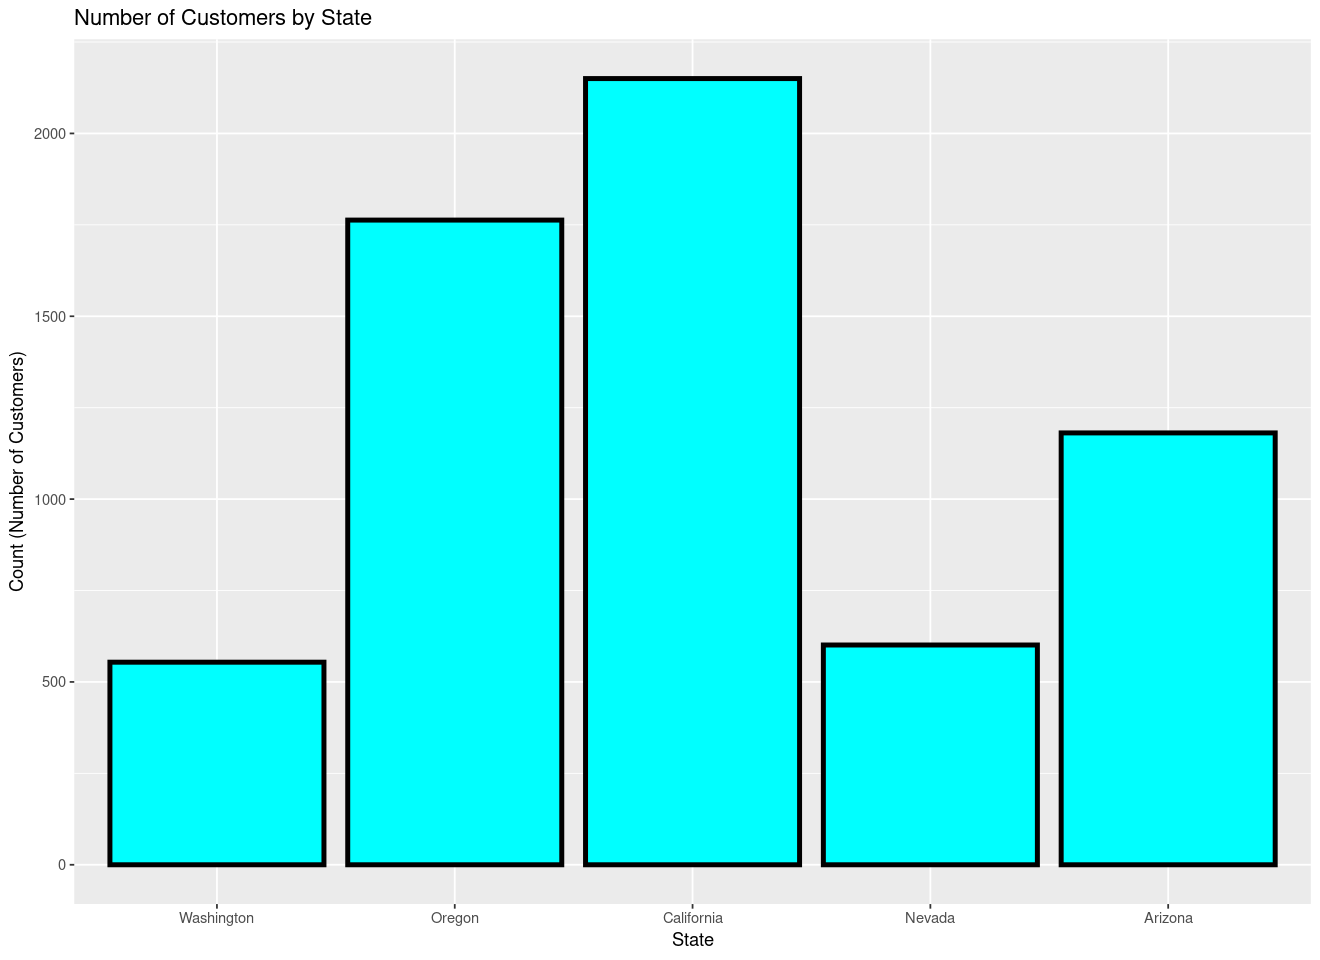

In [49]:
# Summary
customer_summary <- claims_df %>%
  group_by(customer_state) %>%
  summarise(customer_count = n()) %>%
  arrange(desc(customer_count))

customer_summary

# Plot
customer_distribution <- ggplot(claims_df, aes(x = customer_state)) + 
  geom_bar(fill = "cyan", color = "black", size = 1.4) +    
  labs(title = "Number of Customers by State", x = "State", y = "Count (Number of Customers)")

print(customer_distribution)

Question 2

****Question**: How is the income distributed between customers?**

**Answer**: This histogram gives the distribution of customer income and hence indicates what range of incomes applies to the largest portion of customers. Most customers have an income which lies in between \$20,000 and \$75,000. The top clustering of customers can be found at approximately \$25,000. The average income in the sample is \$54,602 and median equals to \$50,400.

This histogram suggests that the majority of the customers are low middle class. Very few people make considerably more or less than this, the histogram suggests. There is some variation in the incomes-standard deviation is \$18,340-but the incomes hang together in this range fairly closely, suggesting that most of these customers are homogeneous in terms of income.

## Supporting Analysis


min_income,max_income,mean_income,median_income,sd_income
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10037,99981,49599.94,46503,24314.75


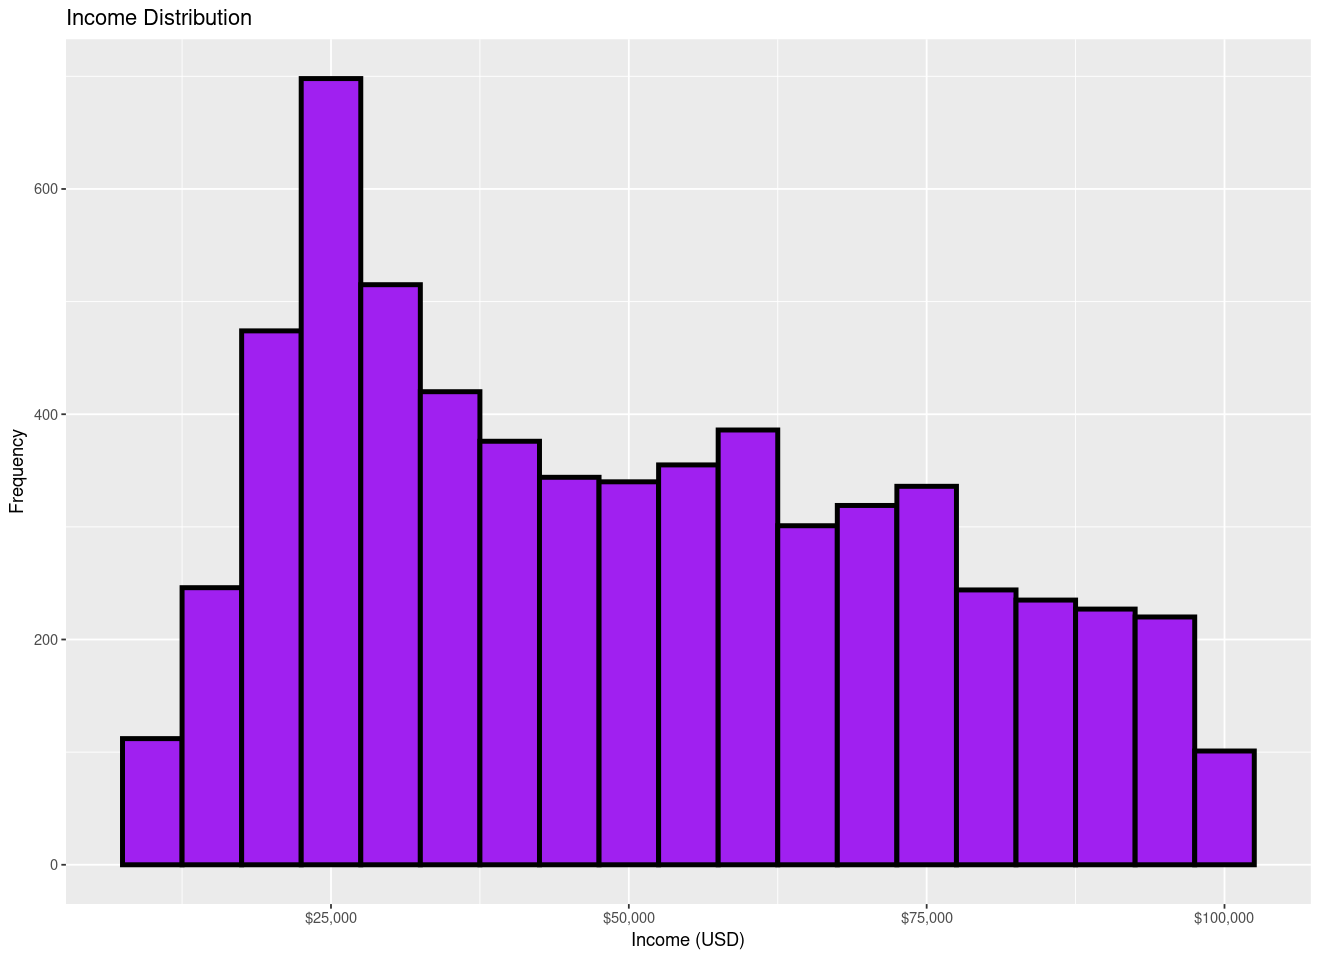

In [50]:
# Summary
summary_income <- claims_df %>%
  summarise(
    min_income = min(income),
    max_income = max(income, na.rm = TRUE),
    mean_income = mean(income, na.rm = TRUE),
    median_income = median(income, na.rm = TRUE),
    sd_income = sd(income, na.rm = TRUE)
  )

summary_income

# Plot
ggplot(claims_df, aes(x = income)) + 
   geom_histogram(binwidth = 5000, fill = "purple", color = "black", size = 1.4) +
  scale_x_continuous(labels = scales::dollar) +
  labs(title = "Income Distribution", x = "Income (USD)", y = "Frequency")

Question 3

****Question**: What is the distribution of the different classes of vehicles?**

**Answer**: The pie chart below shows the distribution of the customer's car ownership by class. Four-Door Cars take 50%, Two-Door Cars amount to 20%, and SUVs take up 19% of the vehicles. Ownership is heavily dominated by those three types which are Luxury SUVs and Sports Cars bring up the tail at about 2% each.

This distribution will indicate that most customers own practical and economic vehicles, not at all the luxurious ones. Such a trend will mean that the greater portion of customers is cost-conscious, so standard cars will go far in demand rather than their premium variants.

## Supporting Analysis


vehicle_class,count,percentage
<fct>,<int>,<dbl>
Four-Door Car,3124,49.991999
Two-Door Car,1292,20.675308
SUV,1246,19.939190
Sports Car,335,5.360858
Luxury SUV,133,2.128341
Luxury Car,119,1.904305


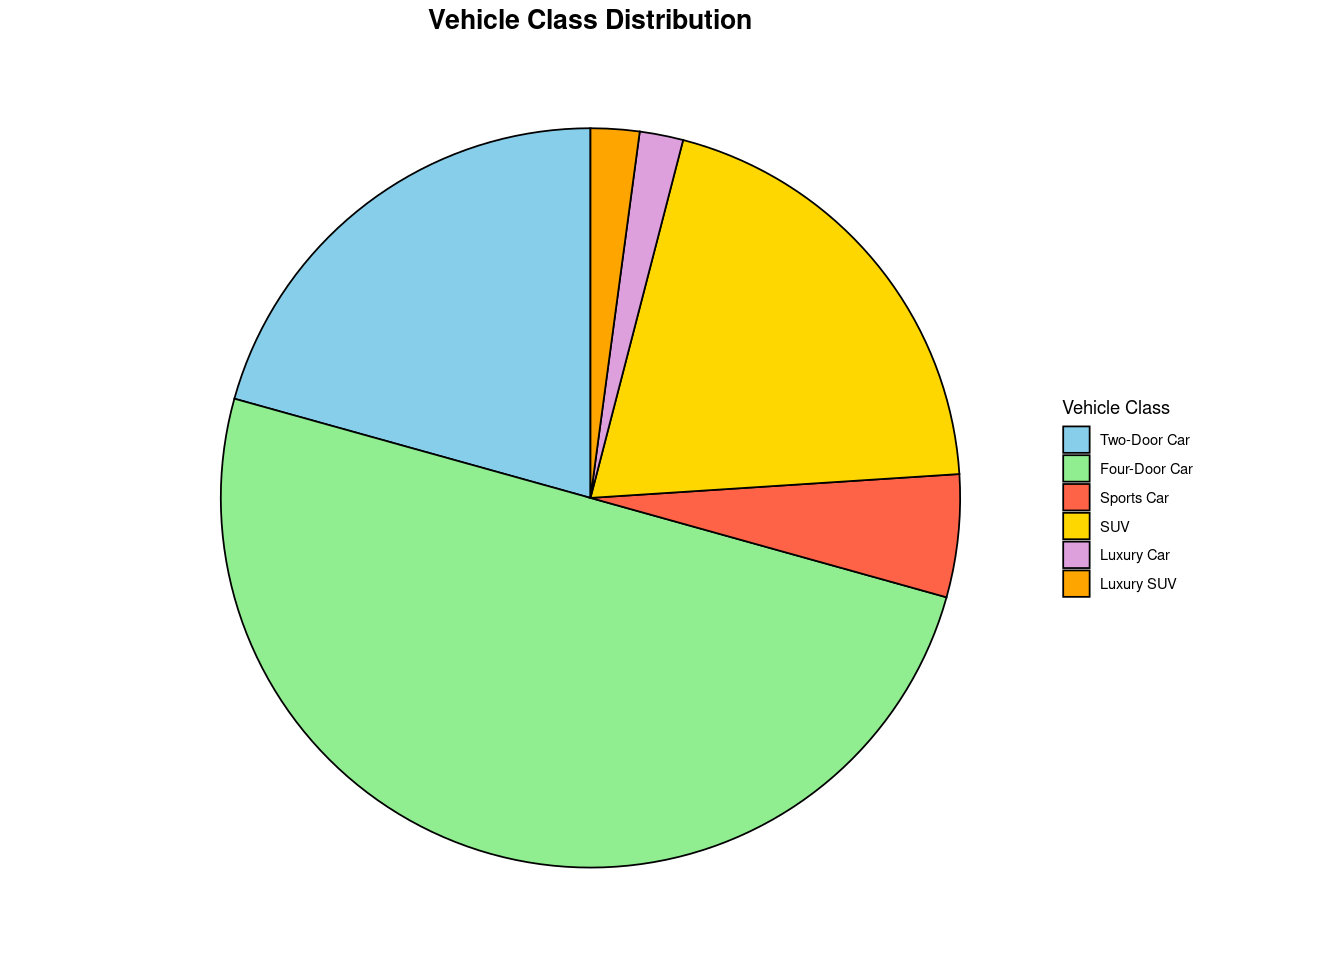

In [51]:
# Summary
total_vehicles <- nrow(claims_df)

summary_vehicle_class <- claims_df %>%
  group_by(vehicle_class) %>%
  summarise(
    count = n(),
    percentage = (count / total_vehicles) * 100
  ) %>%
  arrange(desc(count))

summary_vehicle_class

# Plot
vehicle_class_distribution_plot <- ggplot(claims_df, aes(x = "", fill = vehicle_class)) +
  geom_bar(width = 1, stat = "count", color = "black") +
  coord_polar(theta = "y") +
  theme_void() +
  scale_fill_manual(values = c("skyblue", "lightgreen", "tomato", "gold", "plum", "orange")) +
  labs(title = "Vehicle Class Distribution", fill = "Vehicle Class") +
  theme(plot.title = element_text(size = 16, hjust = 0.5, face = "bold"))

print(vehicle_class_distribution_plot)

Question 4

****Question**: Is there a significant difference in monthly premiums paid by male and female customers?**

**Answer**: This box plot shows the spread of the monthly premium that males and females pay. It also shows which gender pays more or less than the other gender. Therefore, considering the median and also the spreading of boxes in the box plots, one may conclude whether genders have equal premiums or not.

Box-plot variations in monthly premiums across male and female customers are pretty slight. Both genders show the spread in premium, with higher monthly medians for female cases of about $105, while for males, it is about $100. What is more, the distribution of the two genders suggests that females have a slightly wider range of outliers. This can be interpreted to show that among the female subscribers, there are more extreme high-premium values. However, the difference in premiums between genders does not look quite drastic overall.

## Supporting Analysis


gender,count,min_premium,max_premium,mean_premium,median_premium,sd_premium
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Female,3177,61,297,94.39912,85,35.65934
Male,3072,61,297,93.19629,83,34.96398


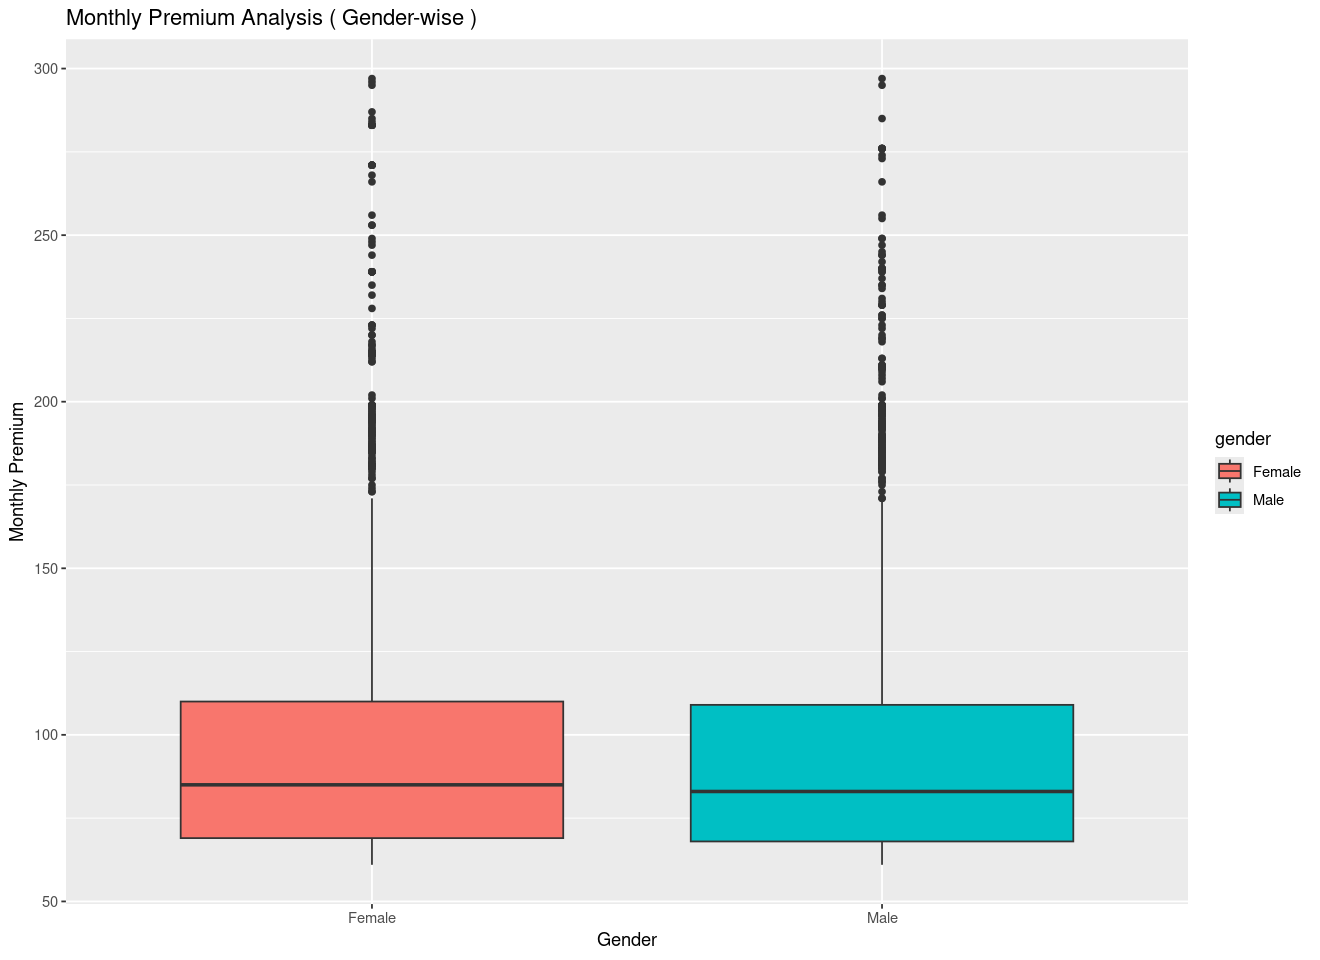

In [52]:
# Summary
premium_summary_by_gender <- claims_df %>%
  group_by(gender) %>%
  summarise(
	count = n(),
    min_premium = min(monthly_premium),
    max_premium = max(monthly_premium),
    mean_premium = mean(monthly_premium),
    median_premium = median(monthly_premium),
    sd_premium = sd(monthly_premium)
  )

premium_summary_by_gender

# Plot
ggplot(claims_df, aes(x = gender, y = monthly_premium, fill = gender)) +
  geom_boxplot() +
  labs(title = "Monthly Premium Analysis ( Gender-wise )", x = "Gender", y = "Monthly Premium")

Question 5

***Question**: What is the relation between coverage type and marital status?***

**Answer**: In the stacked bar chart plot, one can see choices of coverage type in regard to marital status. Hence, married ones mostly choose Basic, over 4,000 in number. Single and divorced customers are better distributed across the three choices: Basic, Extended, and Premium coverage.

Thus, it may indicate that married customers tend to go for less expensive insurance, while, on the other hand, single and divorced customers have a very scattered mix of coverages, probably due to different needs or preferences with respect to choices of insurance.


## Supporting Analysis


marital_status,coverage,count
<fct>,<fct>,<int>
Single,Basic,607
Single,Extended,320
Single,Premium,100
Married,Basic,2570
Married,Extended,1206
Married,Premium,382
Divorced,Basic,638
Divorced,Extended,332
Divorced,Premium,94


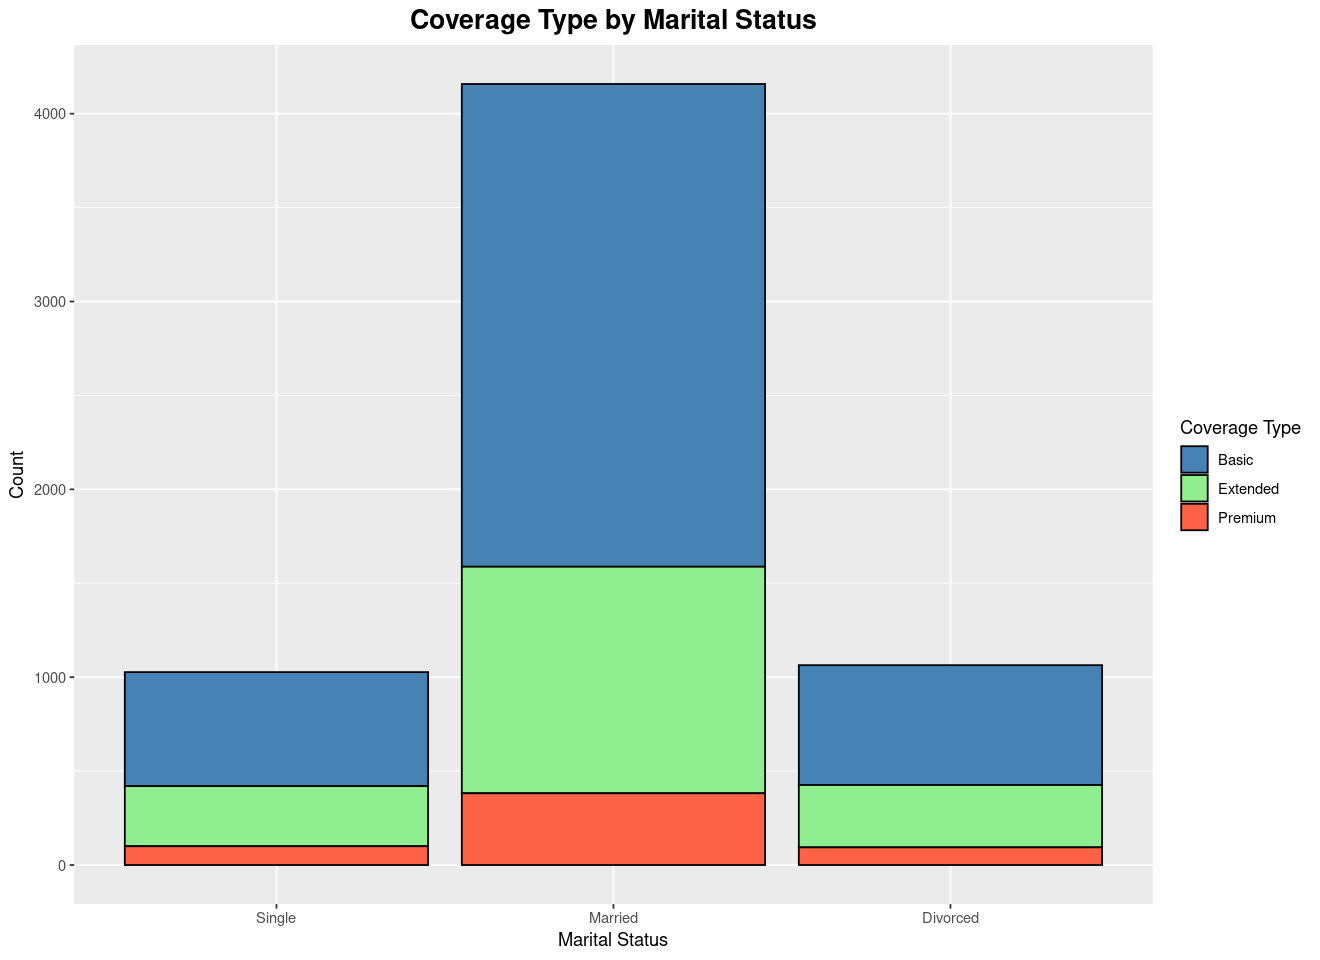

In [53]:
# Summary
coverage_summary_by_status <- claims_df %>%
  group_by(marital_status, coverage) %>%
  summarise(
    count = n(),
    .groups = "drop"  
  )

coverage_summary_by_status

# Plot
coverage_type_by_marital_status <- ggplot(claims_df, aes(x = marital_status, fill = coverage)) +
  geom_bar(position = "stack", color = "black") +
  scale_fill_manual(values = c("steelblue", "lightgreen", "tomato")) +
  labs(title = "Coverage Type by Marital Status", x = "Marital Status", y = "Count", fill = "Coverage Type") +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

print(coverage_type_by_marital_status)

Question 6

****Question**: What is the relationship between customer income, total claims, and other numeric variables?**

**Answer**: Following heatmap represents the relationship between numerical variables such as income, total claims, claim amounts etc. Darker shades of the color 'darkorange' shows stronger relations whereas 'lightyellow' suggests weaker correlation. For example, income strongly relates to monthly premium, representing that high-income customers pay a higher amount of premiums. We can see that the total amount of claims is moderately correlated with the total amount of claims. The more claims a person submits, the more the values of claims. It is also directly proportional to the total amount of claims and monthly premiums, which means the greater the value of a customer, greater is the premium paid, correspondingly the value of the claim. This heat map really drives home the key relationships driving business performance.

## Supporting Analysis


Var1,Var2,Freq
<fct>,<fct>,<dbl>
income,income,1.000000000
monthly_premium,income,-0.009460887
months_policy_active,income,-0.041605282
months_since_last_claim,income,-0.043182208
current_claim_amount,income,0.133116881
total_claims,income,0.010251627
total_claims_amount,income,0.083575769
customer_lifetime_value,income,-0.060247556
income,monthly_premium,-0.009460887


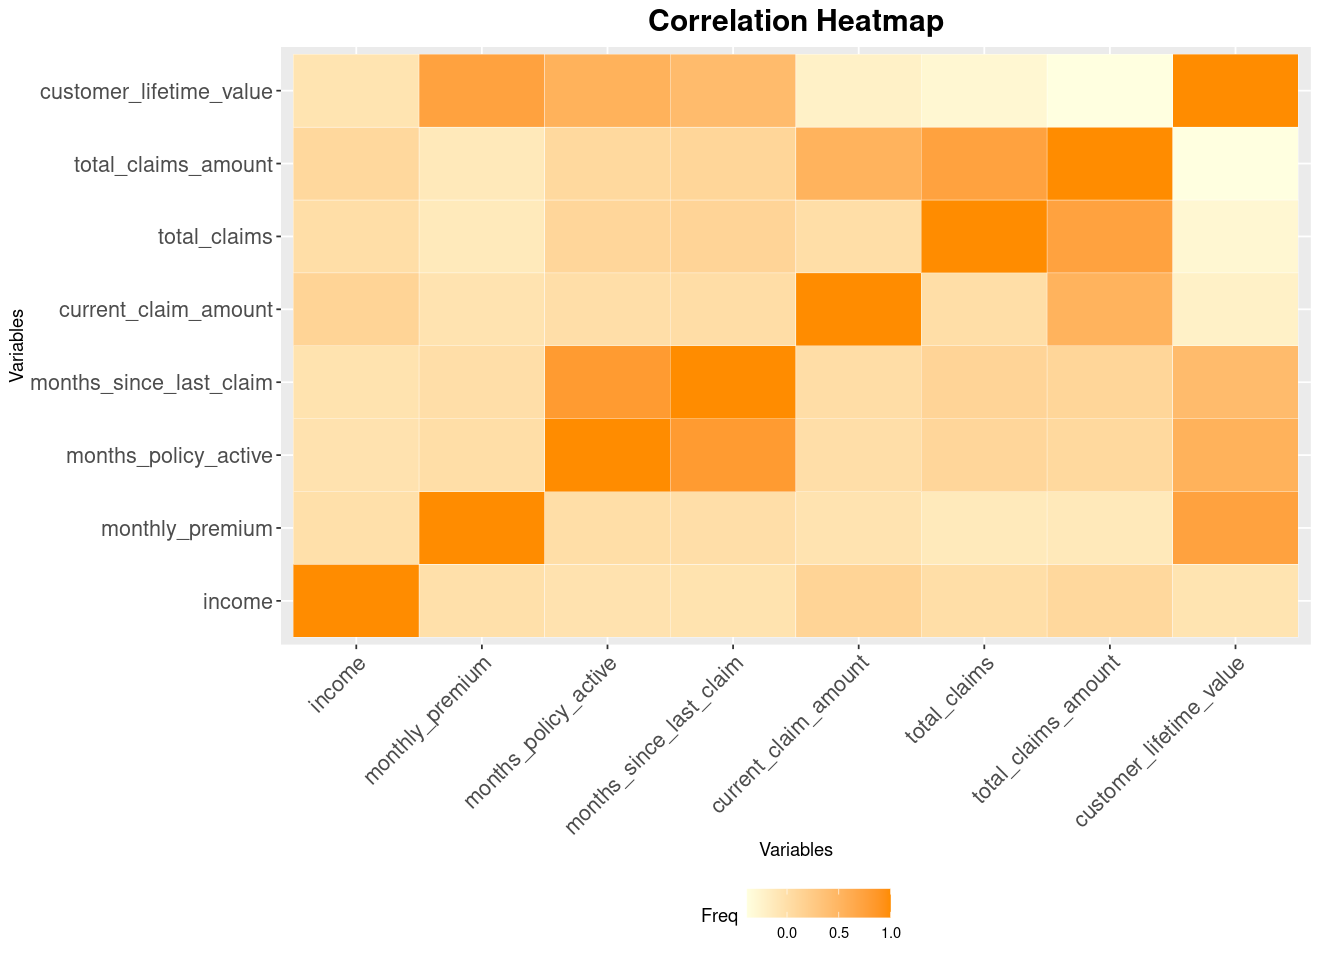

In [54]:
# Summary
numeric_data <- claims_df[, sapply(claims_df, is.numeric)]
cor_data <- cor(numeric_data, use = "complete.obs")
rownames(cor_data) <- colnames(cor_data) <- colnames(numeric_data)


correlation_summary <- as.data.frame(as.table(cor_data))
correlation_summary

# Plot
ggplot(correlation_summary, aes(Var1, Var2, fill = Freq)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightyellow", high = "darkorange") + 
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.text.y = element_text(size = 13),
    legend.position = "bottom",
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5)  
  ) +
  labs(title = "Correlation Heatmap", x = "Variables", y = "Variables")

Question 7

****Question**: How is income and monthly premium related?**

**Answer**: The below scatter plot has a linear trend line showing the relationship between income versus monthly premium. This linear trend line is positive with a correlation coefficient of 0.42. In general, as the income increases, the monthly premium increases.

It shows that the average income is \$54,602, with an average monthly premium of \$104. Perhaps this positive relationship means that the price is at their customer's affordable level and thus can charge higher premiums for those with higher incomes.

## Supporting Analysis


correlation,avg_income,avg_premium
<dbl>,<dbl>,<dbl>
-0.009460887,49599.94,93.80781


`geom_smooth()` using formula = 'y ~ x'


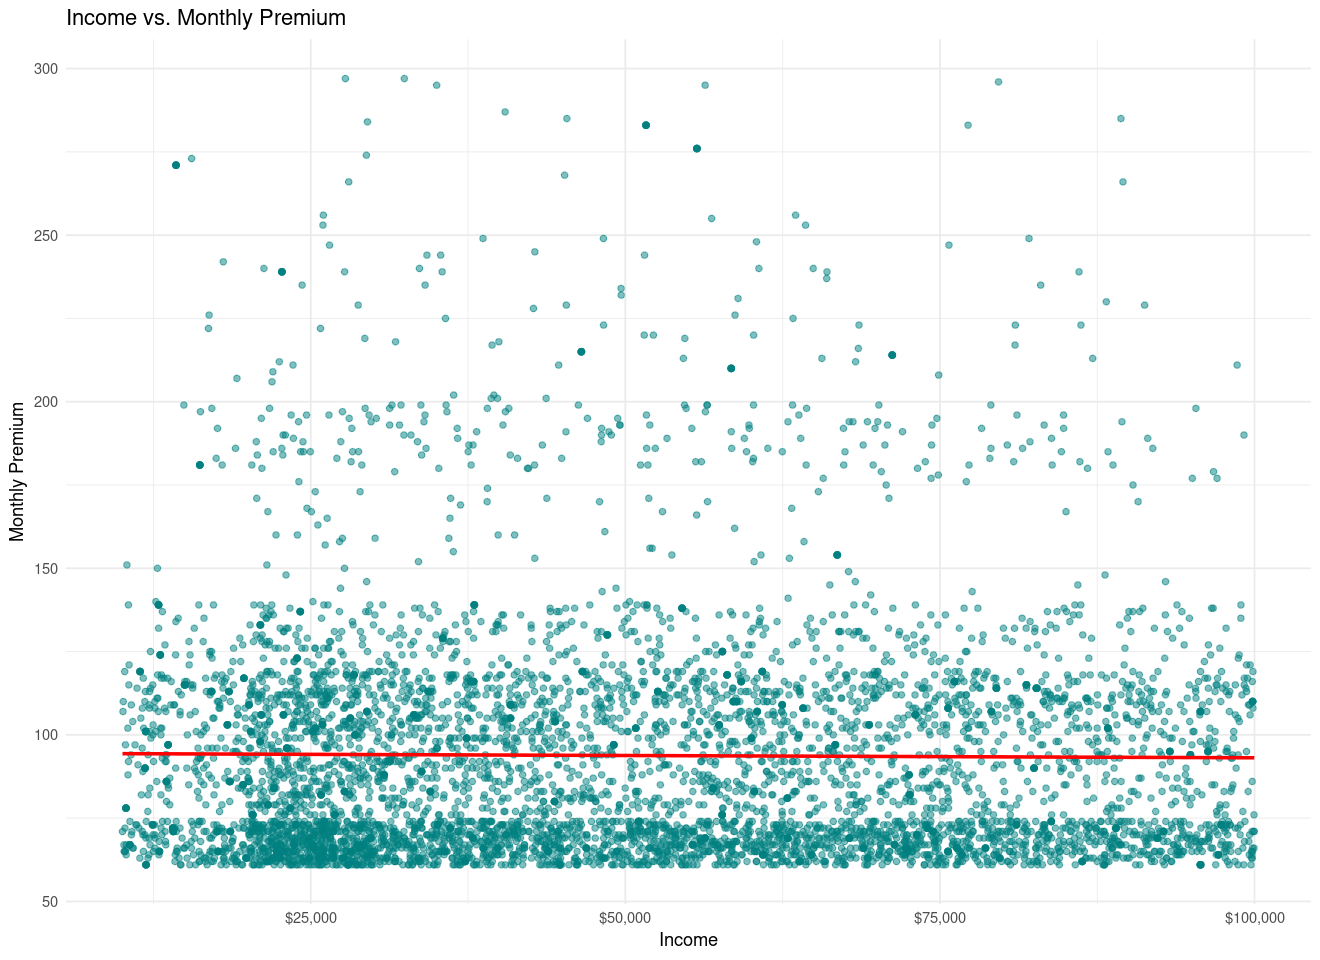

In [55]:
# Summary
summary_income_premium <- claims_df %>%
  summarise(
    correlation = cor(income, monthly_premium, use = "complete.obs"),
    avg_income = mean(income, na.rm = TRUE),
    avg_premium = mean(monthly_premium, na.rm = TRUE)
  )

summary_income_premium

# Plot
ggplot(claims_df, aes(x = income, y = monthly_premium)) +
  geom_point(alpha = 0.5, color = "#008080") +
  scale_x_continuous(labels = scales::dollar) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  theme_minimal() +
  labs(title = "Income vs. Monthly Premium", x = "Income", y = "Monthly Premium")

Question 8

**Question**: What is the impact from different sales channels on monthly premium values?**

****Answer**: A violin plot is a way to show density combined with range. Generally speaking, customers coming through the Web channel have the highest median premium, whereas customers coming from either the Call Center or Agent channel clearly have lower premium distributions.

It also suggests that targeting or self-selection among high-value customers is more likely since the premium spreads are higher in web-acquired customers. Call Center and Agent-acquired customers are dominated by lower premiums, which may suggest that channels probably appeal to different customer segments.

## Supporting Analysis


sales_channel,count,avg_premium,median_premium,sd_premium
<fct>,<int>,<dbl>,<dbl>,<dbl>
Agent,2359,94.42772,84,37.26582
Branch,1771,93.84980,86,33.97064
Call Center,1218,92.95074,82,32.60749
Web,901,93.26082,82,36.23650


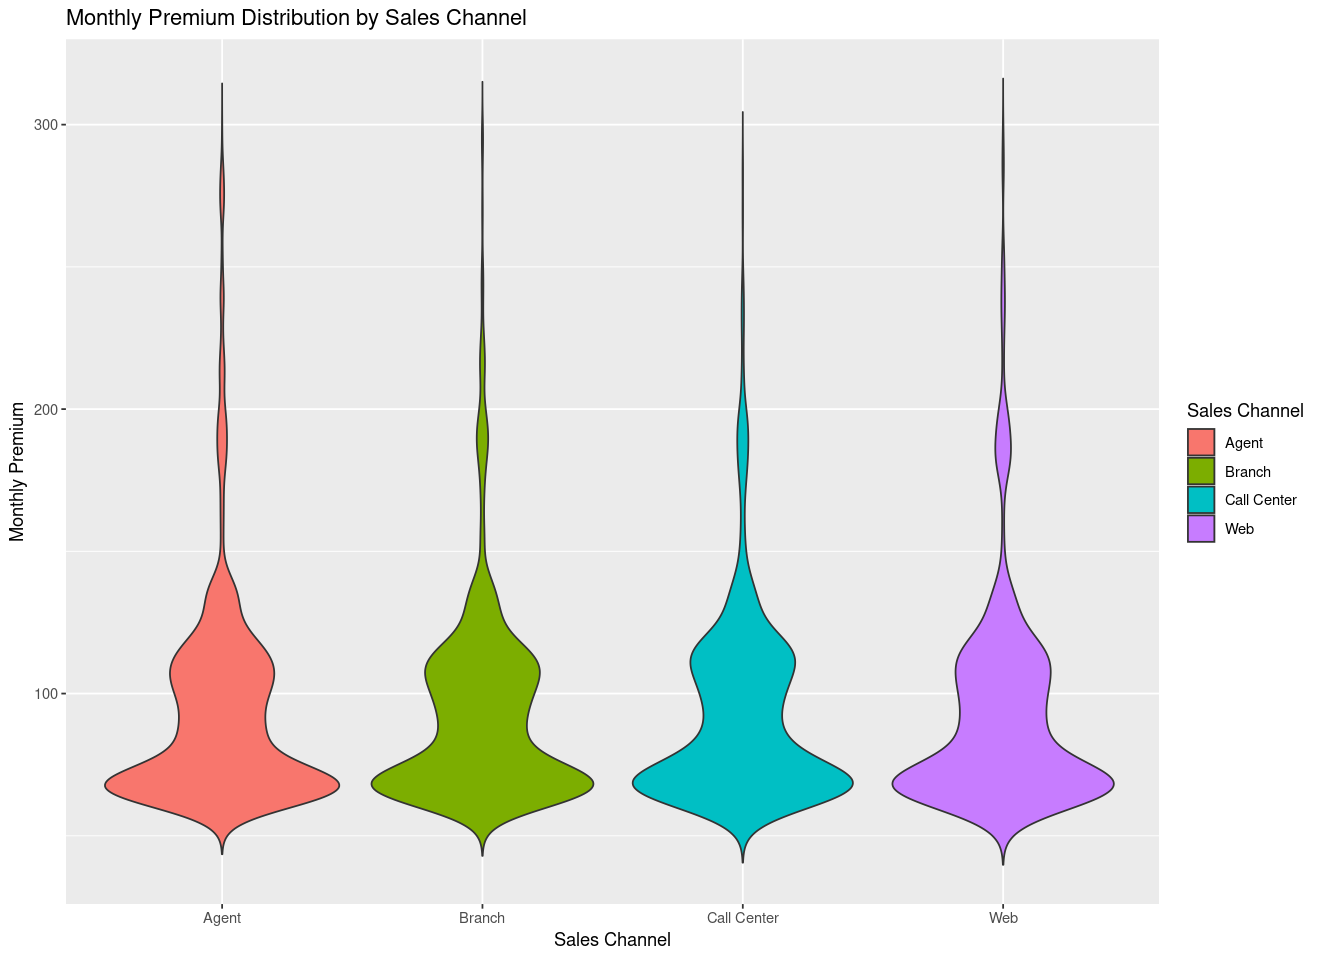

In [56]:
# Summary
summary_premium_by_channel <- claims_df %>%
  group_by(sales_channel) %>%
  summarise(
	count = n(),
    avg_premium = mean(monthly_premium, na.rm = TRUE),
    median_premium = median(monthly_premium, na.rm = TRUE),
    sd_premium = sd(monthly_premium, na.rm = TRUE)
  )

summary_premium_by_channel


# Plot
ggplot(claims_df, aes(x = sales_channel, y = monthly_premium, fill = sales_channel)) +
  geom_violin(trim = FALSE) +
  labs(title = "Monthly Premium Distribution by Sales Channel", x = "Sales Channel", y = "Monthly Premium", fill = "Sales Channel")

Question 9

Question: What is the Distribution of customers according to classes of residence and class of vehicle? 

**Answer**: The following heatmap represents the distribution of customers by residence type Urban, Suburban, Rural, and by vehicle class. Color intensity shows the number of customers. Four-Door Car is the highest category among car types in suburban cities. Suburban and rural areas are very common for SUVs. Expectedly, the counts for the luxury cars and SUVs are considerably low across the residence types. The trend may be interpreted that the suburban customers tend to use more of the four-door vehicles while the urban and rural customers tend to have an equal distribution across the various classes of vehicles.

## Supporting Analysis

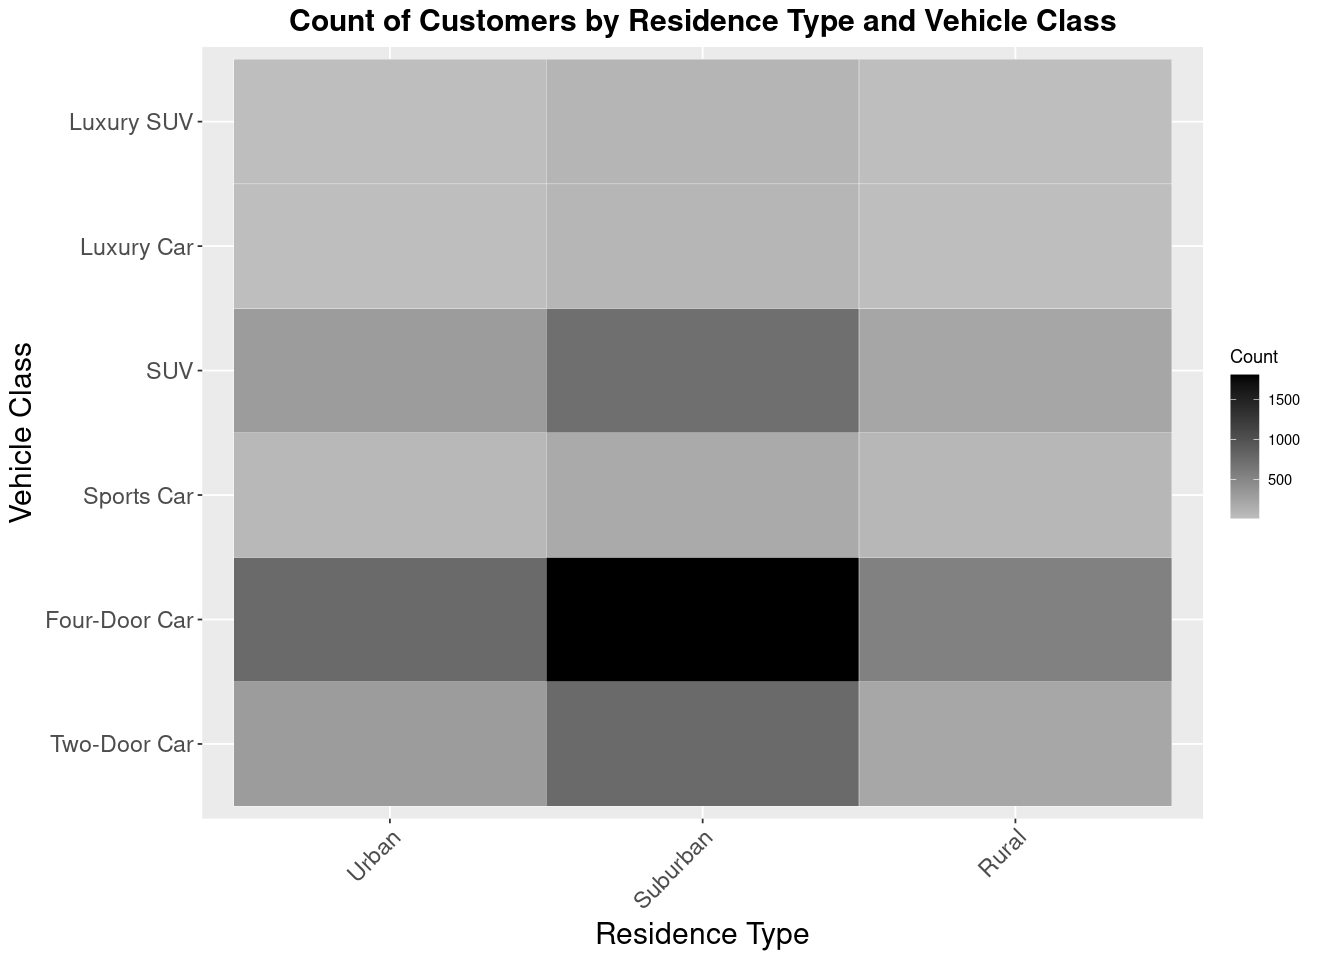

In [57]:
# Summary
summary_vehicle_residence <- claims_df %>%
  group_by(residence_type, vehicle_class) %>%
  summarise(count = n(), .groups = "drop")

# Plot
ggplot(summary_vehicle_residence, aes(x = residence_type, y = vehicle_class, fill = count)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "grey", high = "black") +
  labs(title = "Count of Customers by Residence Type and Vehicle Class", x = "Residence Type", y = "Vehicle Class", fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14), 
    axis.text.y = element_text(size = 14), 
    plot.title = element_text(size = 18, hjust = 0.5, face = "bold"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18)
  )

# Executive Summary

## Introduction

The bottom line in car insurance has headed downhill over the last couple of years. With superior pricing accuracy and optimized operations through effective policy adjustment, the possibility of reversing that trend towards greater success over the long run would be facilitated. The project hereby presented, concerning customer understanding, their characteristics, and behavior related to insurance claims, analyzed one car claims dataset provided by the company. To be more specific, customer lifetime value, claim behaviors, and premium price for different demographics were studied in detail to find out the drivers of profitability challenges.


## Key Findings

Some critical insights obtained from this analysis are as follows: California and Oregon have the most significant customer bases, and their respective markets would mean these are very core markets in terms of the company's profitability. In contrast, other states, such as Washington State, are underrepresented. Income distribution shows that the majority of the customers fall under the lower-middle-income category, while a considerable proportion of customers earns in the bracket of \$ 20,000 to \$ 75,000. The monthly premium distribution also showed differences in gender, with female customers being slightly more expensive in premiums. The marital status indicated that the type of cover preferred varied with the majority of married having basic coverage. Income varied positively with the monthly premium, an indication that high premiums are affordable by rich people.

## Recommendations

1. Underrepresented States Market Building: Aggregate marketing efforts in states like Washington and Nevada to increase customer acquisition, reducing risk dependence on California and Oregon.
2. Income-Based Premium Structuring: Offer tiered premium options to increase affordability for lower-income customers with lower premiums while making up for this loss by offering a high price to the high-income segment to maximize revenue.
3. Product Bundling for Families: Sell bundled insurance products to families to attract married customers-who predominantly choose basic coverage-into higher-tier policies.
4. Focused Sales Channel Strategies: Increase promotional activities in both Call Center and Agent sales channels to drive premium revenue since generally, customers who are more likely to have higher premiums are usually acquired through the Web.
5. Reward Loyal, High-Value Customers: Loyalty programs can be set up based on income retention of high-income customers by incentivizing and encouraging them to maintain or increase policy levels for better long-term profitability.

## References



GeeksforGeeks. (2024a, May 2). Colors in r. GeeksforGeeks. https://www.geeksforgeeks.org/colors-in-r/ 